# Fitting impedance spectra

## 1. Import and initialize equivalent circuit(s)

To begin we will import the Randles' circuit and a custom circuit from the impedance package. A full list of currently available circuits are available in the [documentation](https://impedancepy.readthedocs.io/en/latest/circuits.html).

In [ ]:
from impedance_extend.models.circuits import Randles, CustomCircuit

The classes we just imported represent different equivalent circuit models. To actually use them we want to initialize a specific instance and provide an initial guess for the parameters and any other options.

*E.g. for the randles circuit, one of the options is for a constant phase element (CPE) instead of an ideal capacitor.*

In [ ]:
randles = Randles(initial_guess=[.01, .005, .001, 200, .1])
randlesCPE = Randles(initial_guess=[.01, .005, .001, 200, .1, .9], CPE=True)

Defining the custom circuit works a little differently. Here we pass a string comprised of the circuit elements grouped either in series (separated with a `-`) or in parallel (using the form `p(X,Y)`). Each element can be appended with an integer (e.g. `R0`) or an underscore and an integer (e.g. `CPE_1`) to make keeping track of multiple elements of the same type easier.

In [ ]:
customCircuit = CustomCircuit(initial_guess=[.01, .005, .1, .005, .1, .001, 200],
                              circuit='R_0-p(R_1,C_1)-p(R_2,C_2)-Wo_1')

As of version 0.4, you can now specify values you want to hold constant. For example,

In [ ]:
customConstantCircuit = CustomCircuit(initial_guess=[None, .005, .1, .005, .1, .001, None],
                                      constants={'R_0': 0.02, 'Wo_1_1': 200},
                                      circuit='R_0-p(R_1,C_1)-p(R_2,C_2)-Wo_1')

Each of the circuit objects we create can be printed in order to see the properties that have been defined for that circuit.

In [ ]:
print(customConstantCircuit)


Circuit string: R_0-p(R_1,C_1)-p(R_2,C_2)-Wo_1
Fit: False

Constants:
    R_0 = 2.00e-02 [Ohm]
  Wo_1_1 = 2.00e+02 [sec]

Initial guesses:
    R_1 = 5.00e-03 [Ohm]
    C_1 = 1.00e-01 [F]
    R_2 = 5.00e-03 [Ohm]
    C_2 = 1.00e-01 [F]
  Wo_1_0 = 1.00e-03 [Ohm]



## 2. Formulate data

Several convenience functions for importing data exist in the impedance_extendpreprocessing module, including one for reading simple `.csv` files where frequencies are stored in the first column, real parts of the impedance are in the second column, and imaginary parts of the impedance are in the third column.

In [ ]:
from impedance_extend import preprocessing

frequencies, Z = preprocessing.readCSV('../../../data/exampleData.csv')

# keep only the impedance data in the first quandrant
frequencies, Z = preprocessing.ignoreBelowX(frequencies, Z)

## 3a. Fit the equivalent circuits to a spectrum

Each of the circuit classes has a `.fit()` method which finds the best fitting parameters.

After fitting a circuit, the fit parameters rather that the inital guesses are shown when printing.

In [ ]:
randles.fit(frequencies, Z)
randlesCPE.fit(frequencies, Z)
customCircuit.fit(frequencies, Z)
customConstantCircuit.fit(frequencies, Z)

print(customConstantCircuit)


Circuit string: R_0-p(R_1,C_1)-p(R_2,C_2)-Wo_1
Fit: True

Constants:
    R_0 = 2.00e-02 [Ohm]
  Wo_1_1 = 2.00e+02 [sec]

Initial guesses:
    R_1 = 5.00e-03 [Ohm]
    C_1 = 1.00e-01 [F]
    R_2 = 5.00e-03 [Ohm]
    C_2 = 1.00e-01 [F]
  Wo_1_0 = 1.00e-03 [Ohm]

Fit parameters:
    R_1 = 6.79e-03  (+/- 1.08e-03) [Ohm]
    C_1 = 5.62e+00  (+/- 1.96e+00) [F]
    R_2 = 3.91e-03  (+/- 1.09e-03) [Ohm]
    C_2 = 1.36e+00  (+/- 2.61e-01) [F]
  Wo_1_0 = 5.88e-02  (+/- 1.25e-03) [Ohm]



## 3b. Fit the equivalent circuits to a spectrum using GA and PSO

We can pass an additional `optimizations` parameter to the `.fit()` method. The `optimizations` could be a dict or a list of dict-s. 

* If optimizations is not passed, or optimizations=[] or {},  curve_fit is used.

* If  `optimizations` is a single dict, 
  * It must include the key "algorithm" to indicate the algorithm to be use. 
  * Other keys in the dict would specify algorithm options. 
  * Eg : {"algorithm" : 'scipy_minimize', 'method' : ...} or {"algorithm" : 'pygad', 'gene_space' : ...}. 
* If `optimizations` is a list of dicts,
  * The individual dicts should follow the above specification. 
  * The circuit fit would perform sequential optimization using the algorithms specified (for example it might be useful to run a gradient search following GA).
* We can add `"show_progress" : True` to show progress (default=`True`) and `"plot" : True` (default=`False`) to plot optimizations dict
* It is recommended to pass `scale` denoting the order of magnitude of the parameters in order to improve convergence.
  * Consider a p(R,C) or R-C circuit. 
  * Suppose C-s is in μF while, R-s might be in ~0.1 ohms; we can pass [0.1,1e-6].
  * Internally the parameters are divided by scale during optimization.

  * For the following example, since initial guess is R_1 = 5.00e-03 [Ohm], C_1 = 1.00e-01 [F], R_2 = 5.00e-03 [Ohm], C_2 = 1.00e-01 [F], Wo_1_0 = 1.00e-03 [Ohm], the fitting function will infer a scale of [1e-2,10,1e-2,1e-1,1e-3].
  * Alternately, since our final result is R_1 = 6.79e-03 [Ohm], C_1 = 5.62e+00 [F], R_2 = 3.91e-03 [Ohm], C_2 = 1.36e+00 [F], Wo_1_0 = 5.88e-02 [Ohm], we might use scale=[1e-2,10,1e-3,1,1e-1]


fitting.py:280: UserWarning: 'scale' is recommeded for least_squares. Using scale from initial_guess.



Circuit string: R_0-p(R_1,C_1)-p(R_2,C_2)-Wo_1
Fit: True

Constants:
    R_0 = 2.00e-02 [Ohm]
  Wo_1_1 = 2.00e+02 [sec]

Initial guesses:
    R_1 = 5.00e-03 [Ohm]
    C_1 = 1.00e-01 [F]
    R_2 = 5.00e-03 [Ohm]
    C_2 = 1.00e-01 [F]
  Wo_1_0 = 1.00e-03 [Ohm]

Fit parameters:
    R_1 = 6.79e-03  (+/- 0.00e+00) [Ohm]
    C_1 = 5.62e+00  (+/- 0.00e+00) [F]
    R_2 = 3.91e-03  (+/- 0.00e+00) [Ohm]
    C_2 = 1.36e+00  (+/- 0.00e+00) [F]
  Wo_1_0 = 5.88e-02  (+/- 0.00e+00) [Ohm]



fitting.py:280: UserWarning: 'scale' is recommeded for pygad. Using scale from initial_guess.


Circuit fit using pygad (default method):   0%|          | 0/1000 [00:00<?, ?it/s]

validation.py:670: UserWarning: The percentage of genes to mutate (mutation_percent_genes=10) resulted in selecting (0) genes. The number of genes to mutate is set to 1 (mutation_num_genes=1).
If you do not want to mutate any gene, please set mutation_type=None.


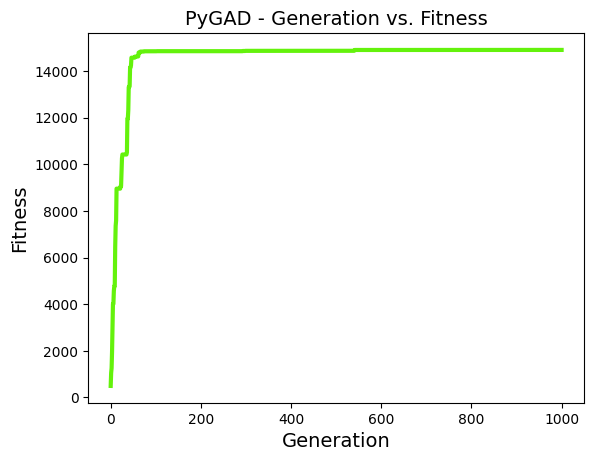


Circuit string: R_0-p(R_1,C_1)-p(R_2,C_2)-Wo_1
Fit: True

Constants:
    R_0 = 2.00e-02 [Ohm]
  Wo_1_1 = 2.00e+02 [sec]

Initial guesses:
    R_1 = 5.00e-03 [Ohm]
    C_1 = 1.00e-01 [F]
    R_2 = 5.00e-03 [Ohm]
    C_2 = 1.00e-01 [F]
  Wo_1_0 = 1.00e-03 [Ohm]

Fit parameters:
    R_1 = 8.61e-03  (+/- 0.00e+00) [Ohm]
    C_1 = 3.24e+00  (+/- 0.00e+00) [F]
    R_2 = 2.09e-03  (+/- 0.00e+00) [Ohm]
    C_2 = 1.50e+00  (+/- 0.00e+00) [F]
  Wo_1_0 = 5.88e-02  (+/- 0.00e+00) [Ohm]



fitting.py:280: UserWarning: 'scale' is recommeded for pyswarms. Using scale from initial_guess.


Circuit fit using pyswarms (default method):   0%|          | 0/1000 [00:00<?, ?it/s]


Circuit string: R_0-p(R_1,C_1)-p(R_2,C_2)-Wo_1
Fit: True

Constants:
    R_0 = 2.00e-02 [Ohm]
  Wo_1_1 = 2.00e+02 [sec]

Initial guesses:
    R_1 = 5.00e-03 [Ohm]
    C_1 = 1.00e-01 [F]
    R_2 = 5.00e-03 [Ohm]
    C_2 = 1.00e-01 [F]
  Wo_1_0 = 1.00e-03 [Ohm]

Fit parameters:
    R_1 = 9.03e-03  (+/- 0.00e+00) [Ohm]
    C_1 = 2.85e+00  (+/- 0.00e+00) [F]
    R_2 = 1.55e-03  (+/- 0.00e+00) [Ohm]
    C_2 = 2.75e+00  (+/- 0.00e+00) [F]
  Wo_1_0 = 5.88e-02  (+/- 0.00e+00) [Ohm]



Circuit fit using pygad (default method):   0%|          | 0/1000 [00:00<?, ?it/s]

...

Circuit fit using least_squares (default method): 0it [00:00, ?it/s]


Circuit string: R_0-p(R_1,C_1)-p(R_2,C_2)-Wo_1
Fit: True

Constants:
    R_0 = 2.00e-02 [Ohm]
  Wo_1_1 = 2.00e+02 [sec]

Initial guesses:
    R_1 = 5.00e-03 [Ohm]
    C_1 = 1.00e-01 [F]
    R_2 = 5.00e-03 [Ohm]
    C_2 = 1.00e-01 [F]
  Wo_1_0 = 1.00e-03 [Ohm]

Fit parameters:
    R_1 = 6.79e-03  (+/- 0.00e+00) [Ohm]
    C_1 = 5.62e+00  (+/- 0.00e+00) [F]
    R_2 = 3.91e-03  (+/- 0.00e+00) [Ohm]
    C_2 = 1.36e+00  (+/- 0.00e+00) [F]
  Wo_1_0 = 5.88e-02  (+/- 0.00e+00) [Ohm]



Circuit fit using pygad (default method):   0%|          | 0/1000 [00:00<?, ?it/s]

Circuit fit using least_squares (default method): 0it [00:00, ?it/s]


Circuit string: R_0-p(R_1,C_1)-p(R_2,C_2)-Wo_1
Fit: True

Constants:
    R_0 = 2.00e-02 [Ohm]
  Wo_1_1 = 2.00e+02 [sec]

Initial guesses:
    R_1 = 5.00e-03 [Ohm]
    C_1 = 1.00e-01 [F]
    R_2 = 5.00e-03 [Ohm]
    C_2 = 1.00e-01 [F]
  Wo_1_0 = 1.00e-03 [Ohm]

Fit parameters:
    R_1 = 6.79e-03  (+/- 0.00e+00) [Ohm]
    C_1 = 5.62e+00  (+/- 0.00e+00) [F]
    R_2 = 3.91e-03  (+/- 0.00e+00) [Ohm]
    C_2 = 1.36e+00  (+/- 0.00e+00) [F]
  Wo_1_0 = 5.88e-02  (+/- 0.00e+00) [Ohm]



In [ ]:
bounds=[(0,0.1),(0,100),(0,0.01),(0,10),(0,1)]

# least_squares
optimizations={'algorithm':'least_squares'}
customConstantCircuit.fit(frequencies, Z, optimizations=optimizations, bounds=bounds)
print(customConstantCircuit)

# GA
optimizations={'algorithm':'pygad', 'plot' : True}
customConstantCircuit.fit(frequencies, Z, optimizations=optimizations, bounds=bounds)
print(customConstantCircuit)

# PSO
optimizations={'algorithm':'pyswarms'}
customConstantCircuit.fit(frequencies, Z, optimizations=optimizations, bounds=bounds)
print(customConstantCircuit)

# Sequential optimization of GA followed by least_squares
scale=[1e-2,10,1e-3,1,1e-1]
optimizations=[{'algorithm':'pygad'},{'algorithm':'least_squares'}]
customConstantCircuit.fit(frequencies, Z, optimizations=optimizations, scale=scale, bounds=bounds)
print(customConstantCircuit)

# Sequential optimization of GA followed by least_squares
scale=[1e-2,10,1e-3,1,1e-1]
optimizations=[{'algorithm':'pygad'},{'algorithm':'least_squares'}]
customConstantCircuit.fit(frequencies, Z, optimizations=optimizations, scale=scale, bounds=bounds)
print(customConstantCircuit)

# Sequential optimization of GA followed by least_squares (with soft_constraint)
import numpy as np
sig = lambda x : 1 / (1 + np.exp(-10*x))
soft_constraint = lambda p: 10*sig(p[0]*p[1]-p[2]*p[3])
optimizations = [{'algorithm': 'pygad'},
                    {'algorithm': 'least_squares'}]
customConstantCircuit.fit(frequencies, Z, optimizations=optimizations, scale=scale, bounds=bounds, 
                          soft_constraint=soft_constraint)
print(customConstantCircuit)


## 3c. Obtain the GA and PSO optimization object

fitting.py:280: UserWarning: 'scale' is recommeded for pygad. Using scale from initial_guess.


validation.py:670: UserWarning: The percentage of genes to mutate (mutation_percent_genes=10) resulted in selecting (0) genes. The number of genes to mutate is set to 1 (mutation_num_genes=1).
If you do not want to mutate any gene, please set mutation_type=None.


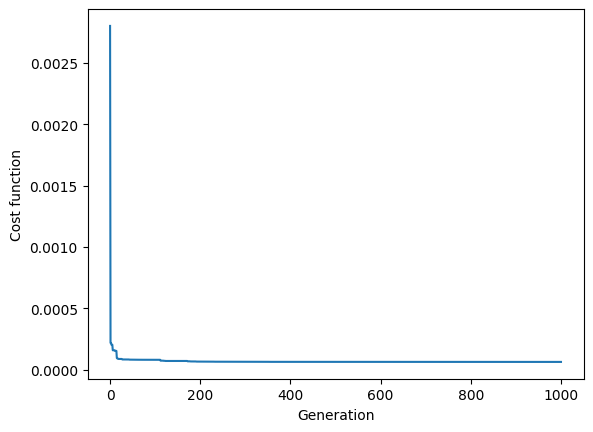

fitting.py:280: UserWarning: 'scale' is recommeded for pyswarms. Using scale from initial_guess.


Circuit fit using pyswarms (default method):   0%|          | 0/1000 [00:00<?, ?it/s]

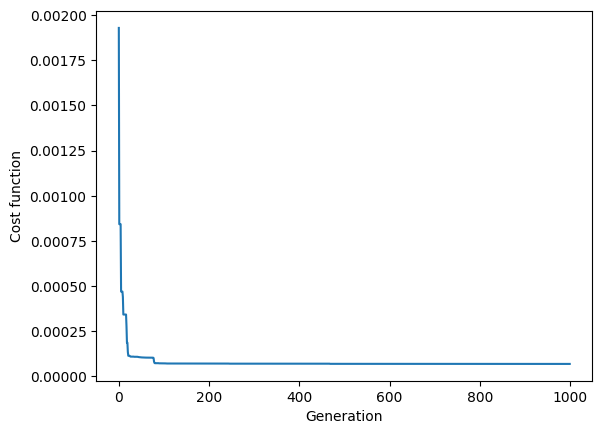

In [ ]:
import matplotlib.pyplot as plt

# GA
optimizations={'algorithm':'pygad', 'plot' : False}
_, optobj = customConstantCircuit.fit(frequencies, Z, optimizations=optimizations, bounds=bounds)
history = optobj.best_solutions_fitness
plt.plot(1/np.array(history))
plt.xlabel('Generation')
plt.ylabel('Cost function')
plt.show()

# PSO
optimizations={'algorithm':'pyswarms'}
_,optobj = customConstantCircuit.fit(frequencies, Z, optimizations=optimizations, bounds=bounds)
history = optobj.cost_history
plt.plot(history)
plt.xlabel('Generation')
plt.ylabel('Cost function')
plt.show()


## 4a. Predict circuit model and visualize with matplotlib

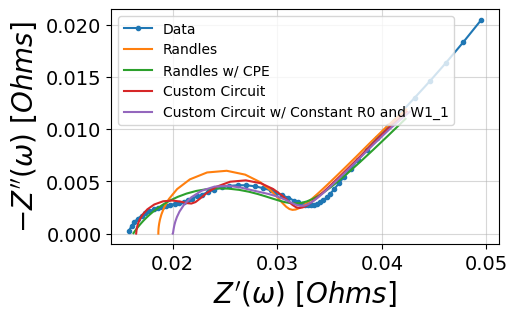

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from impedance_extend.visualization import plot_nyquist

f_pred = np.logspace(5,-2)

randles_fit = randles.predict(f_pred)
randlesCPE_fit = randlesCPE.predict(f_pred)
customCircuit_fit = customCircuit.predict(f_pred)
customConstantCircuit_fit = customConstantCircuit.predict(f_pred)

fig, ax = plt.subplots(figsize=(5,5))

plot_nyquist(Z, ax=ax)
plot_nyquist(randles_fit, fmt='-', ax=ax)
plot_nyquist(randlesCPE_fit, fmt='-', ax=ax)
plot_nyquist(customCircuit_fit, fmt='-', ax=ax)
plot_nyquist(customConstantCircuit_fit, fmt='-', ax=ax)

ax.legend(['Data', 'Randles', 'Randles w/ CPE', 'Custom Circuit', 'Custom Circuit w/ Constant R0 and W1_1'])
plt.show()

## 4b. Or use the convenient plotting method included in the package

visualization.py:39: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string ".-" (-> linestyle='-'). The keyword argument will take precedence.
visualization.py:39: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string ".-" (-> marker='.'). The keyword argument will take precedence.


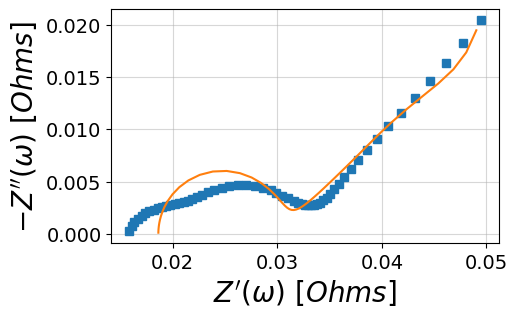

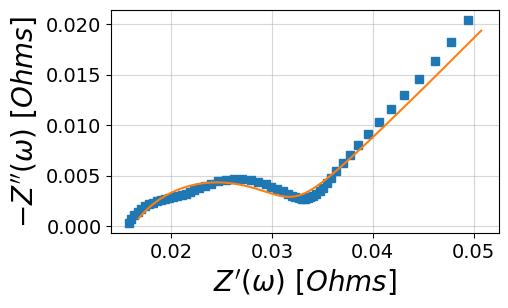

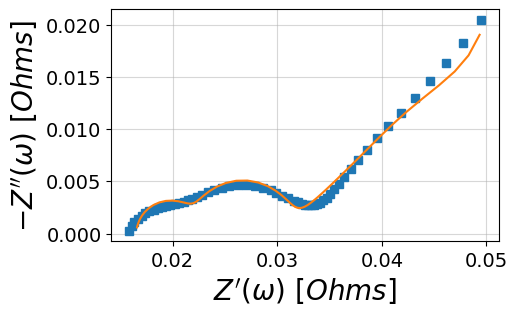

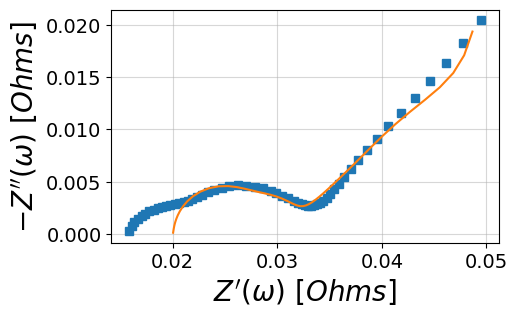

In [ ]:
randles.plot(f_data=frequencies, Z_data=Z, kind='nyquist')
randlesCPE.plot(f_data=frequencies, Z_data=Z, kind='nyquist')
customCircuit.plot(f_data=frequencies, Z_data=Z, kind='nyquist')
customConstantCircuit.plot(f_data=frequencies, Z_data=Z, kind='nyquist')

plt.show()

### Custom circuit elements using the @element decorator

In [ ]:
from impedance_extend.models.circuits.elements import element

@element(1, units=["hands"])
def H(p, f):
    """ A 'pointless' circuit element
    
    Parameters
    ----------
    p : list of numeric
        a list of parameters, e.g. p[0] is used as the radius below
    f : list of numeric
        a list of frequencies in Hz
        
    Returns
    -------
    Z : array of complex
        custom elements should return an array of complex impedance values
    """
    omega = 2*np.pi*np.array(f)
    return p[0]*np.cos(omega) + p[0]*1j*np.sin(omega)

#### Once we've defined our custom element, it can be used in a CustomCircuit

circuits.py:145: UserWarning: Simulating circuit based on initial parameters


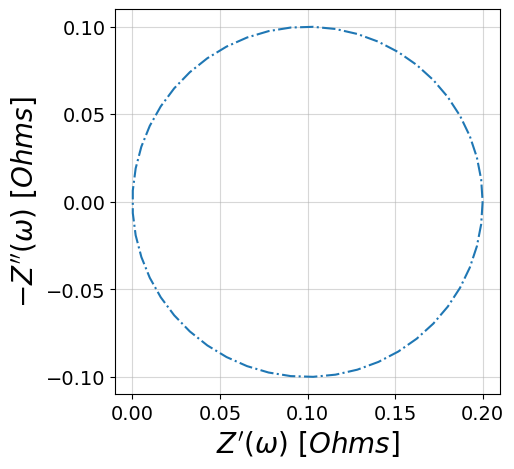

In [ ]:
customElementCircuit = CustomCircuit(initial_guess=[0.1, 0.1], circuit='R_0-H_1')

f_pred = np.linspace(0, 1)

customElementCircuit_fit = customElementCircuit.predict(f_pred)

fig, ax = plt.subplots(figsize=(5,5))
plot_nyquist(customElementCircuit_fit, fmt='-.', ax=ax)
plt.show()